In [4]:


import numpy as np
import neurokit2 as nk
import scipy.signal as ss
from scipy import signal
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### 1. Simula una señal EMG de 30 s dividida en 3 segmentos de 10 s, siguiendo el patrón del ejercicio de fatiga (burst_number decreciente y amplitud creciente).

In [5]:
seg1 = nk.emg_simulate(duration=10, sampling_rate=1000, burst_number=20, burst_duration=0.4, noise=0.01)
seg2 = nk.emg_simulate(duration=10, sampling_rate=1000, burst_number=15, burst_duration=0.5, noise=0.01)
seg3 = nk.emg_simulate(duration=10, sampling_rate=1000, burst_number=10, burst_duration=0.6, noise=0.01)
seg1 *= 1.0
seg2 *= 1.2
seg3 *= 1.4
emg_total = np.concatenate([seg1, seg2, seg3])

### 2. Limpia y extrae la envolvente con nk.emg_clean() + nk.emg_amplitude().

In [6]:
emg_cleaned = nk.emg_clean(emg_total, sampling_rate=1000)
envelope = nk.emg_amplitude(emg_cleaned)

### 3. Divide la envolvente en ventanas de 1 s y para cada ventana calcula el RMS (media de la envolvente) y la frecuencia mediana via Welch (scipy.signal.welch)

In [11]:
fs = 1000
window_size = fs  # 1000 muestras por segundo
n_windows = len(envelope) // window_size

rms_values = []
med_freq = []

for i in range(n_windows):
    window = envelope[i*window_size:(i+1)*window_size]
    rms = np.mean(window)
    rms_values.append(rms)

    f, Pxx = ss.welch(window, fs, nperseg=window_size)
    cum = np.cumsum(Pxx)
    med = f[np.where(cum >= cum[-1]/2)[0][0]]
    med_freq.append(med)


### 4. Ajusta una recta (regresión lineal) al RMS vs. tiempo y otra al freq_med vs. tiempo, y extrae sus pendientes (slope)

In [9]:
times = np.arange(n_windows).reshape(-1, 1)
rms_model = LinearRegression().fit(times, np.array(rms_values).reshape(-1, 1))
freq_model = LinearRegression().fit(times, np.array(med_freq).reshape(-1, 1))
slope_rms = rms_model.coef_[0][0]
slope_freq = freq_model.coef_[0][0]

### 5. Objetivo: comparar dos métricas clásicas de fatiga: la tasa de crecimiento de la amplitud (RMS) y la tasa de caída de la frecuencia mediana.

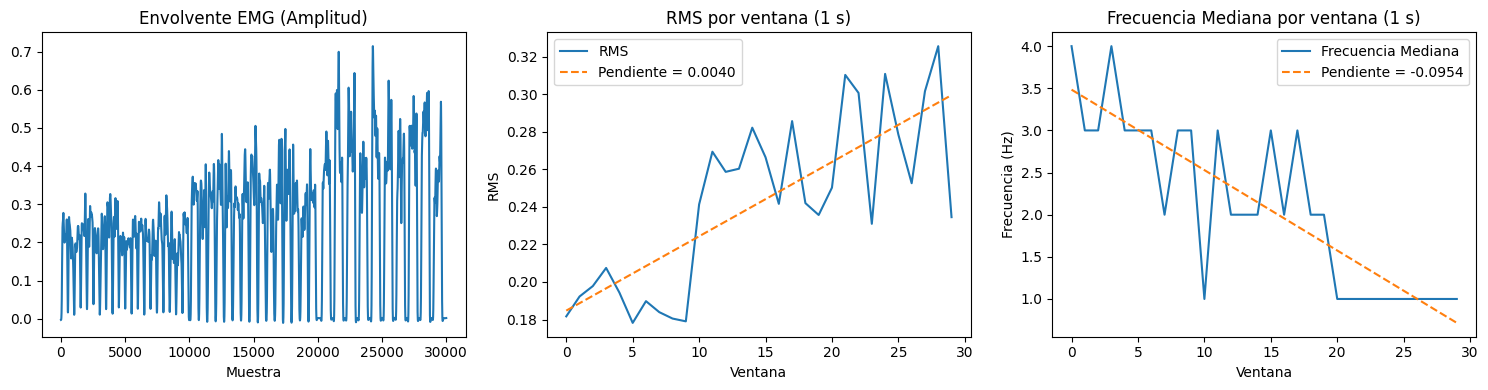

In [10]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(envelope)
plt.title("Envolvente EMG (Amplitud)")
plt.xlabel("Muestra")

plt.subplot(1, 3, 2)
plt.plot(rms_values, label="RMS")
plt.plot(rms_model.predict(times), '--', label=f"Pendiente = {slope_rms:.4f}")
plt.title("RMS por ventana (1 s)")
plt.xlabel("Ventana")
plt.ylabel("RMS")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(med_freq, label="Frecuencia Mediana")
plt.plot(freq_model.predict(times), '--', label=f"Pendiente = {slope_freq:.4f}")
plt.title("Frecuencia Mediana por ventana (1 s)")
plt.xlabel("Ventana")
plt.ylabel("Frecuencia (Hz)")
plt.legend()

plt.tight_layout()
plt.show()